In [1]:
import numpy as np
import pandas as pd
#import tensorflow as tf
from matplotlib import pyplot as plt
#import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from torch.utils.data import TensorDataset, DataLoader, random_split

import torch.optim as optim
import torch.nn as nn

from tqdm import tqdm

import torch.nn.functional as F

Nr = 16 # Nombre d'éléments

# The following lines adjust the granularity of reporting.
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

# 1. Chargement
# Chargement des Data
input_signals = np.load("../Data/X_mvdr_300k.npy")  # Shape attendue: (100000, 3)
output_signals = np.load("../Data/Y_mvdr_300k.npy") # Shape attendue: (100000, 32)

# 2. NORMALISATION DES POIDS (Y)
# On calcule la norme de chaque ligne (chaque vecteur de 32 éléments)
# La norme d'un vecteur complexe w est sqrt(sum(Re^2 + Im^2))
normes = np.linalg.norm(output_signals, axis=1, keepdims=True)
output_signals = output_signals / normes

# 3. NORMALISATION DES ANGLES (X)
input_x = torch.from_numpy(input_signals).float() / 60.0
output_x = torch.from_numpy(output_signals).float()

print(f"Poids normalisés. Nouvelle norme moyenne : {torch.norm(output_x[0]):.4f}")

Poids normalisés. Nouvelle norme moyenne : 1.0000


MVDR_Informed_Network(
  (layer1): Linear(in_features=3, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=512, bias=True)
  (layer3): Linear(in_features=512, out_features=512, bias=True)
  (layer4): Linear(in_features=512, out_features=1024, bias=True)
  (layer5): Linear(in_features=1024, out_features=32, bias=True)
)


/lab/home/labsticc/e2405238/vitualenv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
                                                                                            

Époque [300/300] | Train Loss: 0.007014 | Test Loss: 0.007296


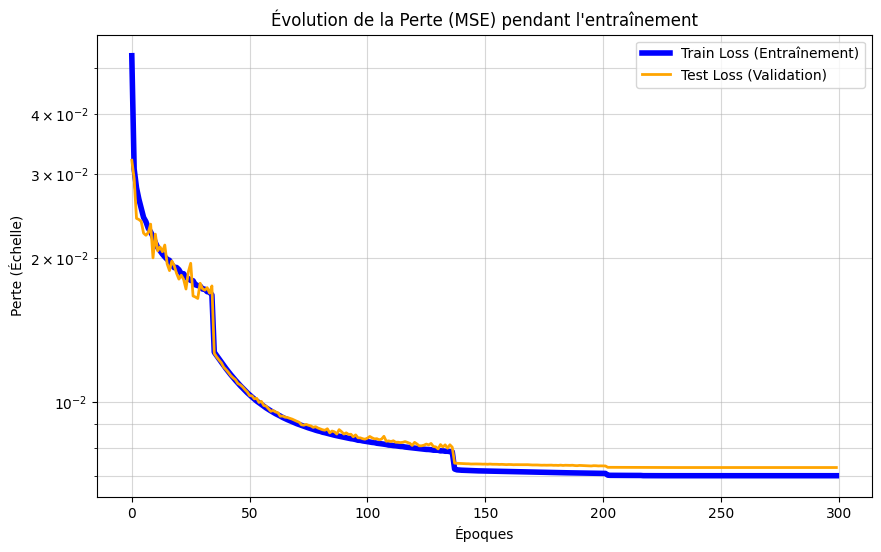

In [3]:
class Layer1(nn.Module):
    def __init__(self, input_size, output_size, use_bias=True):
        super(Layer1, self).__init__()
        self.input_size = input_size
        self.output_size = output_size

        """
        Si le code crash à cause d'un problème de dimension (ce qui arrive souvent en Deep Learning), 
        on pourras facilement faire un print(layer.input_size) pour vérifier si la couche a été créée 
        avec les bonnes tailles. Sans ces lignes, cette information est "perdue" à l'intérieur de la forme 
        des poids.
        """
        
        # Poids standards pour commencer (équivalent à nn.Linear)
        self.weights = nn.Parameter(torch.empty(input_size, output_size))
        if use_bias:
            self.bias = nn.Parameter(torch.empty(output_size))
        else:
            self.register_parameter('bias', None)
            
        # Initialisation propre (Xavier)
        nn.init.xavier_normal_(self.weights)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, x):
        # --- Zone personnalisable : Logique Physique ---
        def calculateF(input_tensor):
            # Pour l'instant, on fait une multiplication simple.
            # Plus tard, insère ici ta récursion Butterfly ou tes délais.
            return torch.matmul(input_tensor, self.weights)

        out = calculateF(x)
        
        if self.bias is not None:
            out += self.bias
            
        return out

class Layer2(nn.Module):
    def __init__(self, size):
        super(Layer2, self).__init__()
        # 'size' doit être le nombre de neurones (ex: 128 ou 256)
        self.W = nn.Parameter(torch.ones(size // 2))
        nn.init.normal_(self.W, mean=1.0, std=0.01)

    def forward(self, x):
        half = x.shape[1] // 2
        top = x[:, :half]
        bottom = x[:, half:]
        
        # L'opération qui crée les "nulls" par opposition de phase
        twiddle = self.W * bottom
        out_top = top + twiddle
        out_bottom = top - twiddle
        
        return torch.cat([out_top, out_bottom], dim=1)
        
class Layer3(nn.Module):
    def __init__(self, size):
        super(Layer3, self).__init__()
        # 'size' doit être le nombre de neurones (ex: 128 ou 256)
        self.W = nn.Parameter(torch.ones(size // 2))
        nn.init.normal_(self.W, mean=1.0, std=0.01)

    def forward(self, x):
        half = x.shape[1] // 2
        top = x[:, :half]
        bottom = x[:, half:]
        
        # L'opération qui crée les "nulls" par opposition de phase
        twiddle = self.W * bottom
        out_top = top + twiddle
        out_bottom = top - twiddle
        
        return torch.cat([out_top, out_bottom], dim=1)

class Layer4(nn.Module):
    def __init__(self, input_size, output_size, use_bias=True):
        super(Layer4, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        
        # Poids standards pour commencer (équivalent à nn.Linear)
        self.weights = nn.Parameter(torch.empty(input_size, output_size))
        if use_bias:
            self.bias = nn.Parameter(torch.empty(output_size))
        else:
            self.register_parameter('bias', None)
            
        # Initialisation propre (Xavier)
        nn.init.xavier_normal_(self.weights)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, x):
        # --- Zone personnalisable : Logique Physique ---
        def calculateF(input_tensor):
            # Pour l'instant, on fait une multiplication simple.
            # Plus tard, insère ici ta récursion Butterfly ou tes délais.
            return torch.matmul(input_tensor, self.weights)

        out = calculateF(x)
        
        if self.bias is not None:
            out += self.bias
            
        return out

# des couches de taille 16, 32, 64, 128, 160 ou 256      #<---------------------------------------------
class MVDR_Informed_Network(nn.Module):
    def __init__(self):
        super(MVDR_Informed_Network, self).__init__()
        self.layer1 = nn.Linear(3, 256)
        self.layer2 = nn.Linear(256, 512)
        self.layer3 = nn.Linear(512, 512)
        self.layer4 = nn.Linear(512, 1024)
        self.layer5 = nn.Linear(1024, 32) # Dernière couche 
        

    def forward(self, x):
        # 1. Les L-1 premières couches cachées utilisent Tanh ou leaky_relu  x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer2(x), 0.1)
        x = F.leaky_relu(self.layer3(x), 0.1)
        x = F.leaky_relu(self.layer4(x), 0.1)
        
        # 2. La L-ième couche cachée (la 4ème ici) utilise Sigmoid
        
        
        # 3. Couche de sortie (Linéaire, sans activation)
        # Indispensable pour que les poids puissent être négatifs
        x = self.layer5(x)
        
        return x

class RMSELoss(nn.Module):      #<---------------------------------------------
    def __init__(self, eps=1e-8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, y_hat, y):
        loss = torch.sqrt(self.mse(y_hat, y) + self.eps)
        return loss

# =================================================================================================================

# =================================================================================================================

def create_model():
    return MVDR_Informed_Network().to(device)

# Device cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Model
model = MVDR_Informed_Network().to(device)
print(model)

# 1. Création du Dataset complet
dataset = TensorDataset(input_x, output_x)

# 2. Division : 80% train, 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 3. Création des DataLoaders
# shuffle=True est CRUCIAL pour que le réseau ne s'habitue pas à l'ordre des données
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Utilisation de la MSE (Mean Squared Error) pour comparer les poids
criterion = RMSELoss()

# AdamW avec un Learning Rate standard
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)        #<---------------------------------------------


# =================================================================================================================


# =================================================================================================================

# Optionnel : Un scheduler pour réduire le LR si la perte stagne
# (Aide à obtenir des "nuls" plus profonds à la fin de l'entraînement)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Initialisation des listes (OBLIGATOIRE avant la boucle)
train_losses = []
test_losses = []
epochs = 300        #<---------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',      # 'min' car on veut minimiser la Loss
    factor=0.1,      # On divise le LR par 10 (ex: 1e-3 devient 1e-4)
    patience=5,      # On attend 5 époques de stagnation avant d'agir
    verbose=True     # Pour qu'il t'affiche un message quand il change le LR
)

for epoch in range(epochs):
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train()
    running_train_loss = 0.0
    loop = tqdm(train_loader, desc=f"Époque [{epoch+1}/{epochs}]", leave=False)
    
    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)        
        # 1. Calcul de la perte via ta classe RMSELoss
        loss = criterion(outputs, targets)        
        # 2. On lance le calcul des gradients sur la perte directe
        loss.backward()       
        # 3. Mise à jour des poids
        optimizer.step()       
        # Mise à jour des compteurs (on utilise .item() pour ne pas stocker le graphe)
        running_train_loss += loss.item()
        loop.set_postfix(train_loss=f"{loss.item():.2e}")

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # --- PHASE DE TEST (VALIDATION) ---
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader: # Utilise le val_loader ici
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_test_loss += loss.item()
    
    epoch_test_loss = running_test_loss / len(val_loader)
    test_losses.append(epoch_test_loss)
    
    # On met à jour le scheduler ReduceLROnPlateau à la fin de l'époque
    scheduler.step(epoch_test_loss)

    # Affichage résumé sur une ligne
# On ajoute end="" pour rester sur la même ligne
print(f"\rÉpoque [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.6f} | Test Loss: {epoch_test_loss:.6f}")

# =================================================================================================================
        
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss (Entraînement)', color='blue', linewidth=4)
plt.plot(test_losses, label='Test Loss (Validation)', color='orange', linewidth=2)

plt.yscale('log') # Très important car ta loss est très petite (ex: 1e-5)
plt.title("Évolution de la Perte (MSE) pendant l'entraînement")
plt.xlabel("Époques")
plt.ylabel("Perte (Échelle)")
plt.grid(True, which="both", alpha=0.5)
plt.legend()
plt.show()
# =================================================================================================================

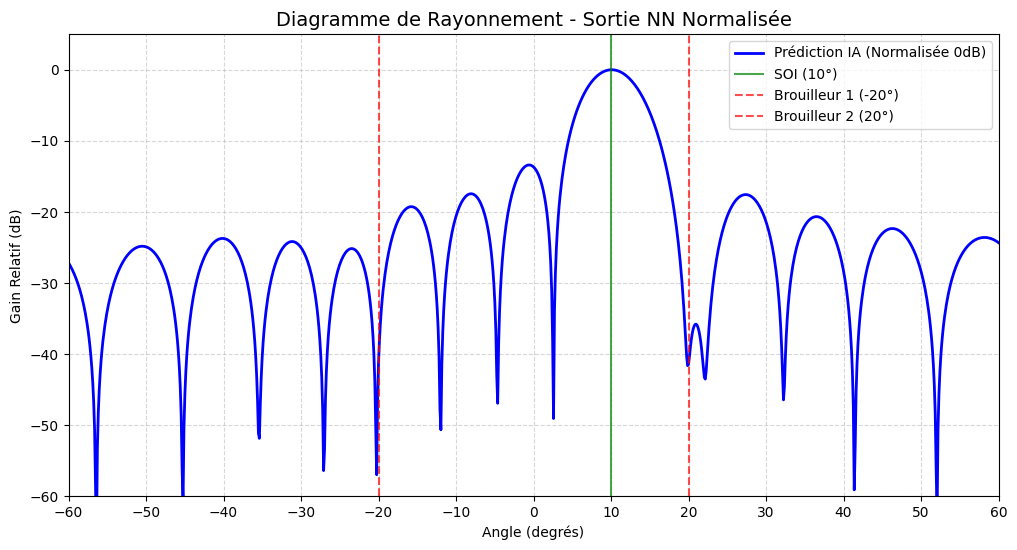

Vérification : Norme du vecteur prédit avant correction finale : 0.9978


In [4]:
# =================================================================================================================

# 1. Fonction du vecteur directeur corrigée (Vecteur plat pour np.vdot)
def get_steering_vector(theta_deg, Nr=16, d=0.5):
    theta_rad = np.deg2rad(theta_deg)
    n = np.arange(Nr) # Vecteur de 0 à 15 (forme 1D)
    return np.exp(2j * np.pi * d * n * np.sin(theta_rad))

# 2. Scénario de test             #<---------------------------------------------
soi_test = 10
soa1_test = -20
soa2_test = 20

# 3. Prédiction du réseau
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    # Entrée normalisée comme à l'entraînement
    entree = torch.tensor([[soi_test, soa1_test, soa2_test]], dtype=torch.float32).to(device) / 60.0
    sortie = model(entree).cpu().numpy().flatten()

# 4. NORMALISATION DU VECTEUR DE SORTIE (Même logique que le dataset)
# On force la norme du vecteur de 32 éléments à 1
norme_ia = np.linalg.norm(sortie)
sortie_norm = sortie / (norme_ia + 1e-12)

# 5. Reconstruction du vecteur de poids complexe (w)
# 16 réels, 16 imaginaires
w_complex = sortie_norm[:16] + 1j * sortie_norm[16:]

# 6. Calcul du diagramme de rayonnement
angles_scan = np.linspace(-60, 60, 1000)
puissance = []

for angle in angles_scan:
    a_theta = get_steering_vector(angle)
    # np.vdot(w, a) calcule w^H * a (produit scalaire complexe)
    valeur_scalaire = np.vdot(w_complex, a_theta)
    puissance.append(np.abs(valeur_scalaire)**2)

puissance = np.array(puissance)

# 7. NORMALISATION À 0 dB POUR L'AFFICHAGE
# On divise par le maximum pour que le lobe principal soit à 0 dB
puissance_relat = puissance / np.max(puissance)
gain_db = 10 * np.log10(puissance_relat + 1e-12)

# 8. Affichage
plt.figure(figsize=(12, 6))
plt.plot(angles_scan, gain_db, label="Prédiction IA (Normalisée 0dB)", color='blue', linewidth=2)

# Indicateurs d'angles
plt.axvline(soi_test, color='green', linestyle='-', alpha=0.7, label=f'SOI ({soi_test}°)')
plt.axvline(soa1_test, color='red', linestyle='--', alpha=0.7, label=f'Brouilleur 1 ({soa1_test}°)')
plt.axvline(soa2_test, color='red', linestyle='--', alpha=0.7, label=f'Brouilleur 2 ({soa2_test}°)')

# Mise en forme
plt.title("Diagramme de Rayonnement - Sortie NN Normalisée", fontsize=14)
plt.xlabel("Angle (degrés)")
plt.ylabel("Gain Relatif (dB)")
plt.xlim([-60, 60])
plt.ylim([-60, 5]) # On laisse un peu de marge au-dessus de 0
plt.xticks(range(-60, 61, 10))
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

print(f"Vérification : Norme du vecteur prédit avant correction finale : {norme_ia:.4f}")

In [ ]:
import os
import matplotlib
# On force le backend "Agg" AVANT d'importer pyplot
matplotlib.use('Agg') 
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Préparation du dossier
folder_name = "models_FFNN"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 2. Génération du nom de base (ID unique)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
base_filename = f"MVDR_Informed_{timestamp}"

# --- SAUVEGARDE DU MODÈLE (.pth) ---
model_path = os.path.join(folder_name, f"{base_filename}.pth")
torch.save(model.state_dict(), model_path)

plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Loss (Entraînement)', color='blue', linewidth=4)
plt.plot(test_losses, label='Test Loss (Validation)', color='orange', linewidth=2)
plt.yscale('log') # Très important car ta loss est très petite (ex: 1e-5)
plt.title(f"Convergence du Modèle - {timestamp}\nArchitecture: 256-512-512-1024-32", fontsize=12)
plt.xlabel("Époques")
plt.ylabel("RMS")
plt.grid(True, which="both", alpha=0.5)

# Légende et affichage des dernières valeurs
last_train = train_losses[-1]
last_test = test_losses[-1]
plt.legend(title=f"Final Train: {last_train:.2e}\nFinal Test: {last_test:.2e}", loc='upper right')

# SAUVEGARDE
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

# ON NE MET PAS plt.show()
plt.close() # Nettoie la mémoire

print(f"📊 Graphique sauvegardé silencieusement : {plot_path}")